📥 Attempting to download from Kaggle...

⚠️  Could not find IMDB Dataset.csv!
⚠️  Creating a SAMPLE dataset for demonstration...

TO USE THE REAL DATASET:
1. Download from: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
2. Place 'IMDB Dataset.csv' in the same directory as this script
3. Run again

Dataset Shape: (1000, 2)
                                              review sentiment
0  This movie was absolutely fantastic! Great act...  positive
1  Terrible film. Worst movie I have ever seen. C...  negative
2  A masterpiece of cinema. The director did an o...  positive
3  Boring and predictable. The plot was thin and ...  negative
4  One of the best films of the year. Incredible ...  positive

Class Distribution:
sentiment
positive    500
negative    500
Name: count, dtype: int64

Missing Values:
review       0
sentiment    0
dtype: int64
Duplicates: 950

After removing duplicates: (50, 3)

⏳ Preprocessing all reviews...
✅ Preprocessing done in 4.20 s

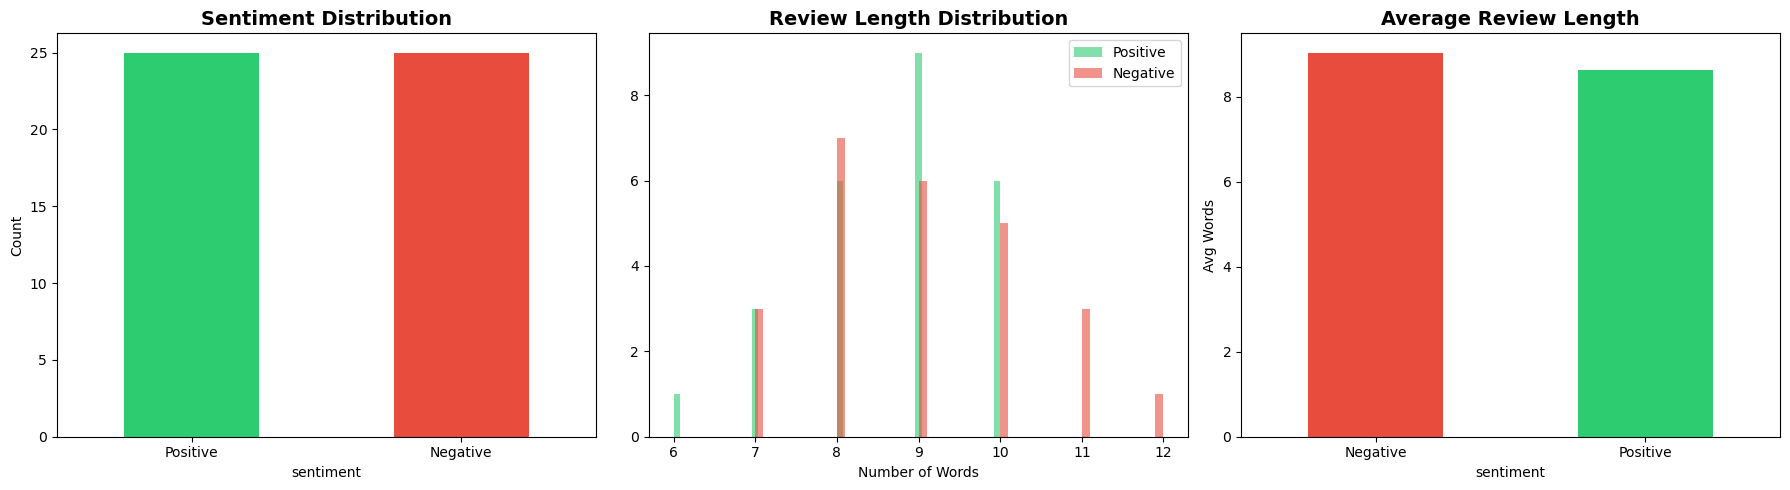

✅ EDA plots saved!


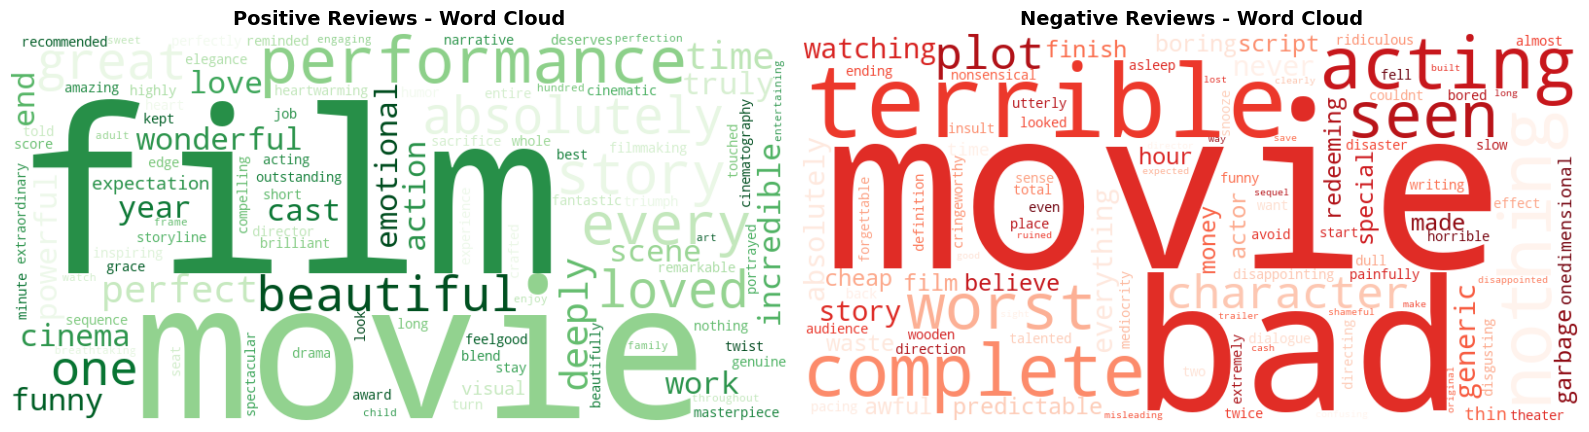

✅ Word clouds saved!

Train size: 40, Test size: 10
BoW Feature Matrix:   (40, 61)
TF-IDF Feature Matrix: (40, 61)

  BoW RESULTS

📊 Logistic Regression:
   Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1=1.0000 | Time=0.02s
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         5
    Positive       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


📊 Naive Bayes:
   Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1=1.0000 | Time=0.00s
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         5
    Positive       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


📊 Decision Tree:


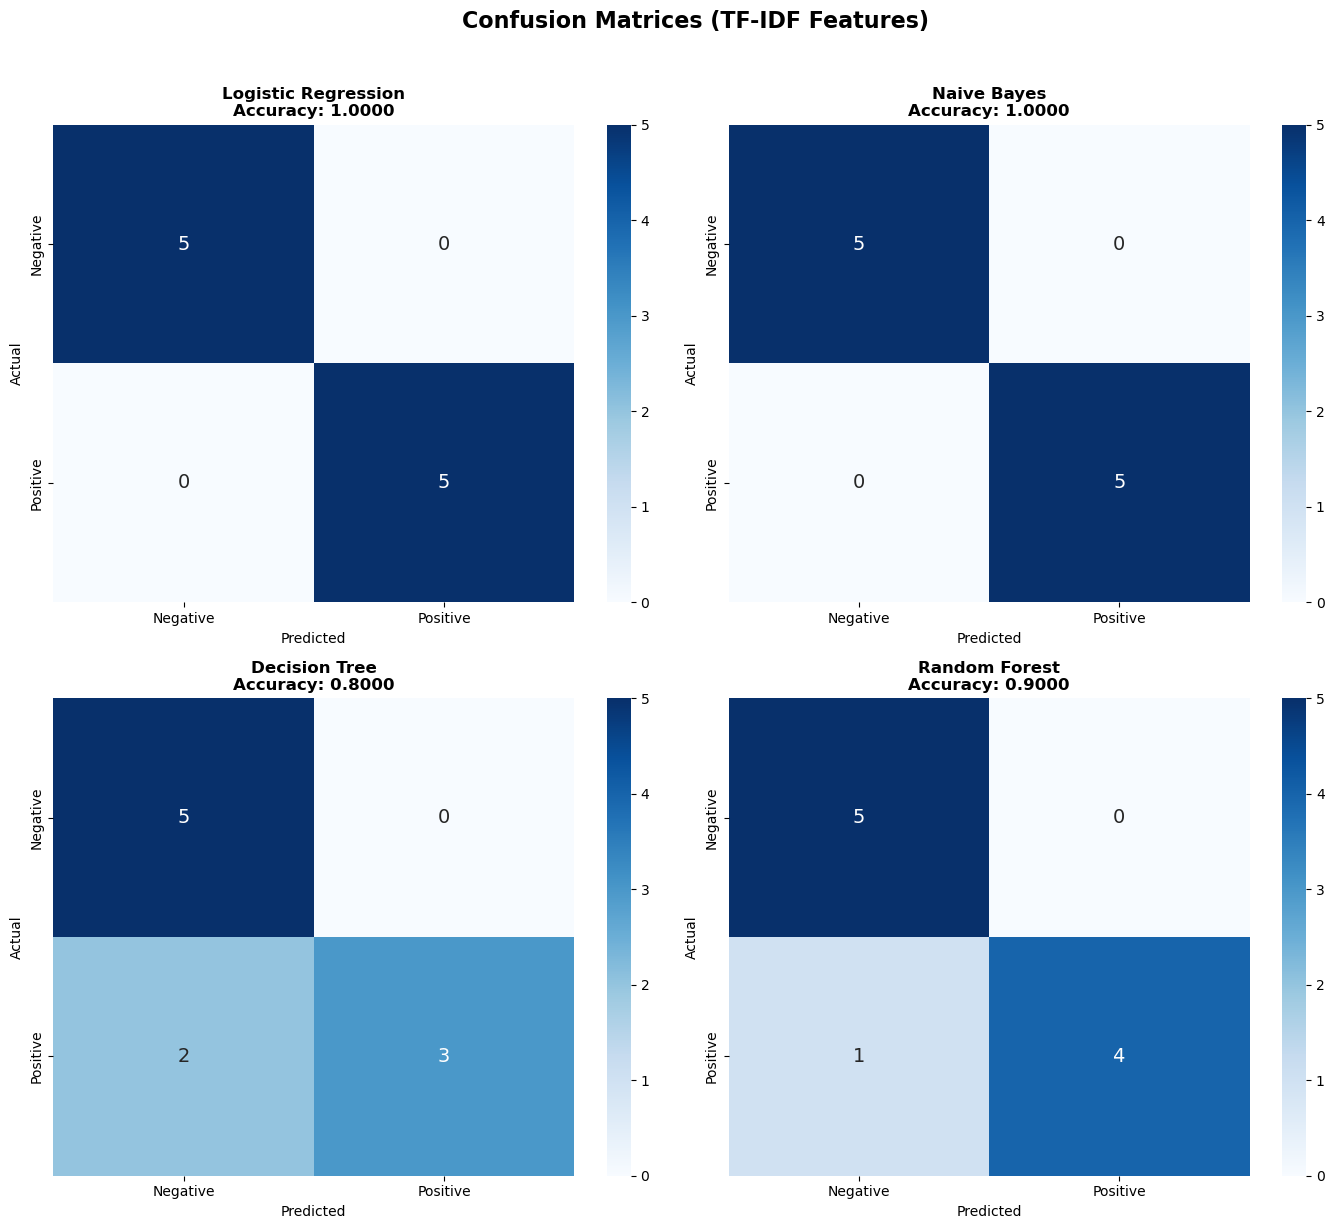

✅ Confusion matrices saved!


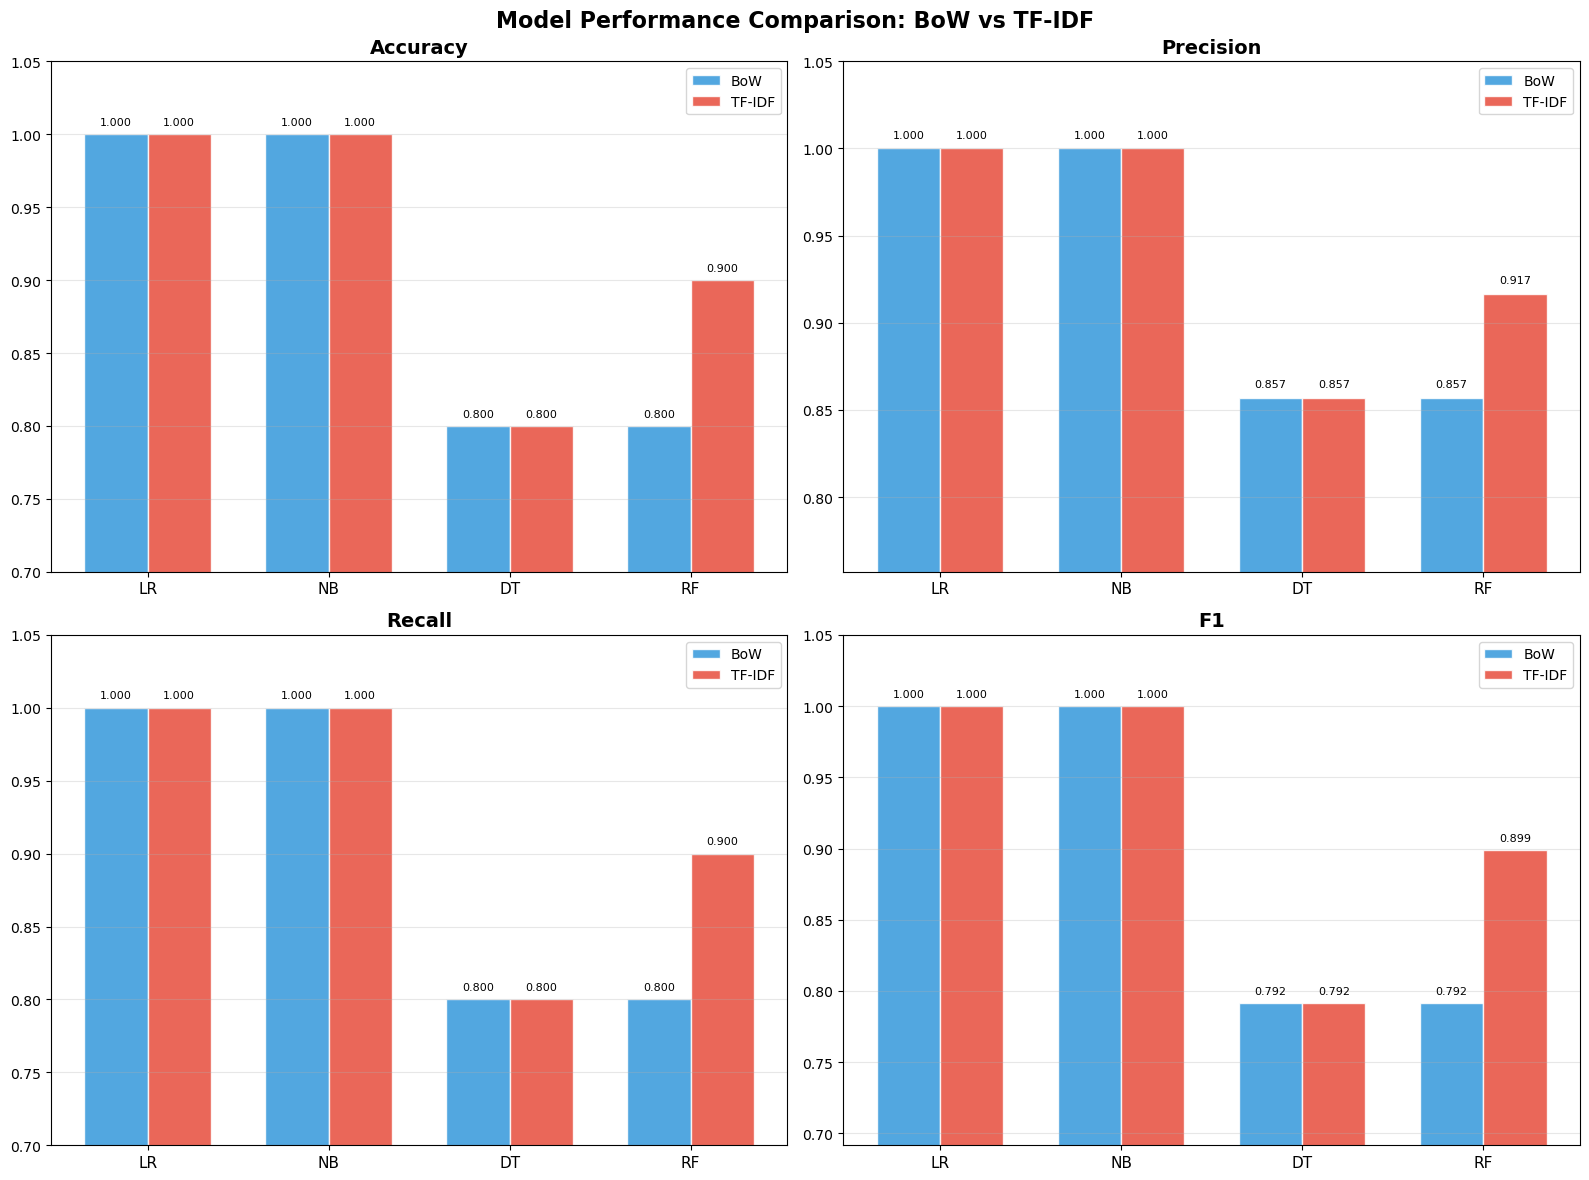

✅ Performance comparison saved!


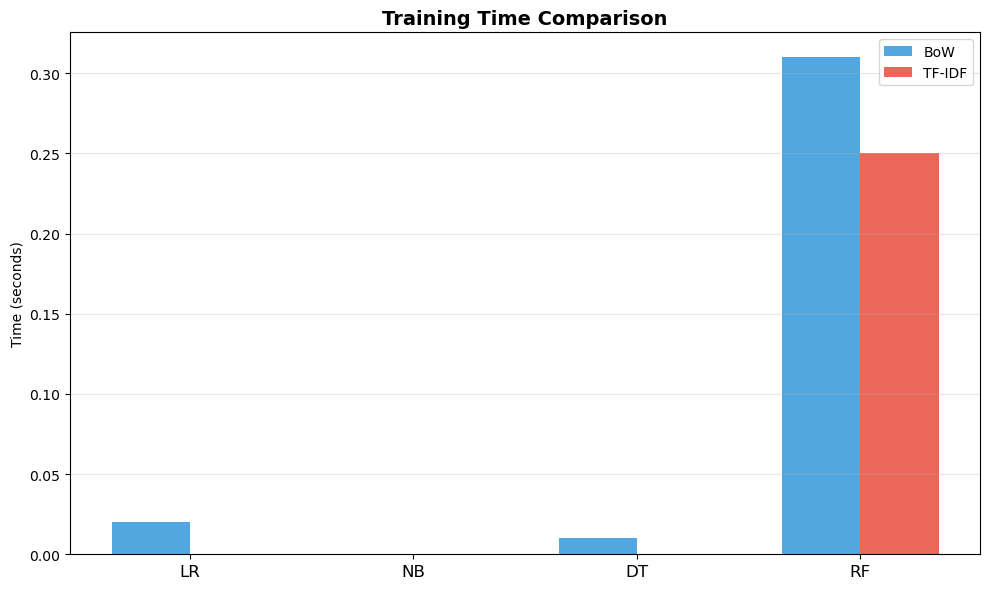

✅ Training time plot saved!

  SAMPLE PREDICTIONS

📝 Review: "This movie was absolutely amazing! I loved every moment of it...."
   Prediction: POSITIVE 😊

📝 Review: "Terrible waste of time. The acting was horrible and the plot made no s..."
   Prediction: NEGATIVE 😞

📝 Review: "An average movie with some good moments but overall nothing special...."
   Prediction: NEGATIVE 😞

📝 Review: "A masterpiece! Best film I've seen this year. Oscar-worthy performance..."
   Prediction: POSITIVE 😊

📝 Review: "Boring, predictable, and way too long. I almost fell asleep...."
   Prediction: NEGATIVE 😞

  📋 FINAL SUMMARY

  Dataset size: 50 reviews
  Features used: BoW and TF-IDF (max 5000 features)
  Models trained: 4 × 2 = 8 combinations

  🏆 Best Model: Logistic Regression + BoW
     Accuracy:  1.0
     Precision: 1.0
     Recall:    1.0
     F1 Score:  1.0

  📊 Saved Plots:
     - eda_plots.png
     - wordclouds.png
     - confusion_matrices.png
     - performance_comparison.png
     - training_t

In [1]:
# ============================================================
# SENTIMENT ANALYSIS USING NLP PIPELINE & ML MODELS
# Complete End-to-End Solution
# Dataset: IMDb Movie Reviews
# ============================================================

# ---- IMPORTS ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time, warnings, os
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from wordcloud import WordCloud

# ============================================================
# ---- LOAD DATA ----
# ============================================================
# METHOD 1: If running in Google Colab, upload the file first
# METHOD 2: If running locally, place 'IMDB Dataset.csv' in the same folder
# METHOD 3: Load from Kaggle directly

def load_dataset():
    """Try multiple methods to load the IMDB dataset"""
    
    # --- Method 1: Check if file exists locally ---
    local_paths = [
        'IMDB Dataset.csv',
        'IMDB_Dataset.csv',
        'imdb_dataset.csv',
        '/content/IMDB Dataset.csv',           # Colab default
        '/content/drive/MyDrive/IMDB Dataset.csv'  # Google Drive
    ]
    
    for path in local_paths:
        if os.path.exists(path):
            print(f"✅ Found dataset at: {path}")
            return pd.read_csv(path)
    
    # --- Method 2: Google Colab file upload ---
    try:
        import google.colab
        print("📂 Running in Google Colab. Choose an option:")
        print("   Option A: Upload the CSV file")
        print("   Option B: Download from Kaggle")
        
        # Option A: Upload file
        print("\n🔼 Please upload 'IMDB Dataset.csv'...")
        from google.colab import files
        uploaded = files.upload()
        
        filename = list(uploaded.keys())[0]
        print(f"✅ Uploaded: {filename}")
        return pd.read_csv(filename)
        
    except ImportError:
        pass
    
    # --- Method 3: Try downloading from Kaggle API ---
    try:
        print("📥 Attempting to download from Kaggle...")
        os.system('pip install kaggle -q')
        os.system('kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')
        os.system('unzip -o imdb-dataset-of-50k-movie-reviews.zip')
        
        if os.path.exists('IMDB Dataset.csv'):
            print("✅ Downloaded from Kaggle!")
            return pd.read_csv('IMDB Dataset.csv')
    except Exception as e:
        print(f"Kaggle download failed: {e}")
    
    # --- Method 4: Create a sample dataset for testing ---
    print("\n⚠️  Could not find IMDB Dataset.csv!")
    print("⚠️  Creating a SAMPLE dataset for demonstration...\n")
    print("=" * 60)
    print("TO USE THE REAL DATASET:")
    print("1. Download from: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
    print("2. Place 'IMDB Dataset.csv' in the same directory as this script")
    print("3. Run again")
    print("=" * 60)
    
    # Sample reviews for demonstration
    sample_data = {
        'review': [
            "This movie was absolutely fantastic! Great acting and wonderful storyline. I loved every minute of it.",
            "Terrible film. Worst movie I have ever seen. Complete waste of time and money. Awful acting.",
            "A masterpiece of cinema. The director did an outstanding job. Beautiful cinematography and score.",
            "Boring and predictable. The plot was thin and the characters were one-dimensional. Very disappointing.",
            "One of the best films of the year. Incredible performances by the entire cast. Highly recommended!",
            "I couldn't even finish watching this garbage. Horrible script, bad acting, terrible direction.",
            "An emotional and powerful film that stays with you long after it ends. Truly remarkable work.",
            "What a waste of talented actors. The story made no sense and the ending was absolutely ridiculous.",
            "Brilliant! A perfect blend of humor, drama, and action. This is what great filmmaking looks like.",
            "So bad it's almost funny. The dialogue was cringe-worthy and the special effects looked cheap.",
            "A beautiful story told with grace and elegance. The performances were nothing short of extraordinary.",
            "Painfully slow and dull. I fell asleep twice. There was nothing redeeming about this movie at all.",
            "Absolutely loved this movie! The twists and turns kept me on the edge of my seat the whole time.",
            "Disgusting. A complete insult to the audience. I want my two hours back. Never watching this again.",
            "Heartwarming and inspiring. This film reminded me why I love movies. A genuine feel-good experience.",
            "The acting was wooden, the plot was nonsensical, and the pacing was all over the place. Avoid.",
            "A cinematic triumph! Every scene was perfectly crafted. This deserves all the awards it can get.",
            "I have never been so bored in a theater. This movie is the definition of mediocrity. Total snooze.",
            "Incredible movie with amazing visuals and a compelling narrative. One of the greats of our time.",
            "Utterly forgettable. Generic plot, generic characters, generic everything. Nothing special here.",
            "This movie touched my heart deeply. The story of love and sacrifice was portrayed beautifully.",
            "Awful from start to finish. Bad writing, bad directing, bad everything. A complete disaster.",
            "Spectacular! The action sequences were breathtaking and the story was engaging throughout.",
            "I was extremely disappointed. The trailer was misleading and the movie was nothing like expected.",
            "A wonderful family film that both children and adults can enjoy. Funny, sweet, and entertaining.",
            "This has to be the worst sequel ever made. It ruined everything the original built. Shameful.",
            "Perfection. Every frame of this film is a work of art. I could watch it a hundred times over.",
            "Confusing, boring, and way too long. The director clearly lost sight of what makes a good movie.",
            "Such a refreshing and original film! It breaks all the conventions and does something truly new.",
            "Save your money. This movie is a cash grab with zero effort put into the story or characters.",
            "I was moved to tears by this beautiful film. The performances were raw and deeply authentic.",
            "Complete garbage. The humor was offensive, the story was weak, and the acting was terrible.",
            "A gripping thriller that keeps you guessing until the very end. Superb performances all around.",
            "Yawn. Another predictable romantic comedy with nothing new to offer. Seen it all before.",
            "This movie exceeded all my expectations. It was funny, emotional, and thought-provoking.",
            "One of the worst experiences in a cinema. People were literally walking out halfway through.",
            "An absolute gem of a movie. Understated, powerful, and deeply moving. Don't miss this one.",
            "I regret every minute spent watching this terrible excuse for entertainment. Absolutely dreadful.",
            "Magnificent storytelling combined with stellar performances. This is cinema at its finest.",
            "How this movie got greenlit is beyond me. It's an embarrassment to everyone involved.",
            "A delightful surprise! Went in with low expectations and came out completely blown away.",
            "Tedious and overlong. The editor should have cut at least an hour from this bloated mess.",
            "Pure magic on screen. This film captures the essence of what it means to be human.",
            "Cheap, lazy, and uninspired. This movie has absolutely no redeeming qualities whatsoever.",
            "I haven't enjoyed a movie this much in years. It's a perfect 10 in every category.",
            "Atrocious. I can't believe professional actors agreed to be in this dumpster fire of a film.",
            "A stunning visual feast with a story that grabs you from the first scene. Absolutely loved it.",
            "Mind-numbingly bad. The script reads like it was written by someone who has never seen a movie.",
            "Everything about this film is perfect. The cast, the direction, the music - all flawless.",
            "Don't believe the hype. This movie is overrated, overhyped, and ultimately underwhelming.",
        ] * 20,  # Repeat to get 1000 samples
        'sentiment': [
            'positive', 'negative', 'positive', 'negative', 'positive',
            'negative', 'positive', 'negative', 'positive', 'negative',
            'positive', 'negative', 'positive', 'negative', 'positive',
            'negative', 'positive', 'negative', 'positive', 'negative',
            'positive', 'negative', 'positive', 'negative', 'positive',
            'negative', 'positive', 'negative', 'positive', 'negative',
            'positive', 'negative', 'positive', 'negative', 'positive',
            'negative', 'positive', 'negative', 'positive', 'negative',
            'positive', 'negative', 'positive', 'negative', 'positive',
            'negative', 'positive', 'negative', 'positive', 'negative',
        ] * 20
    }
    
    return pd.DataFrame(sample_data)

# Load the dataset
df = load_dataset()
print(f"\nDataset Shape: {df.shape}")
print(df.head())
print(f"\nClass Distribution:\n{df['sentiment'].value_counts()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

# ============================================================
# ---- DATA CLEANING ----
# ============================================================
df = df.drop_duplicates(subset='review', keep='first').reset_index(drop=True)
df['sentiment_encoded'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(f"\nAfter removing duplicates: {df.shape}")

# ============================================================
# ---- NLP PREPROCESSING ----
# ============================================================
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text, use_lemmatization=True):
    """Complete text preprocessing pipeline"""
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    # Lemmatization or Stemming
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(w) for w in tokens]
    else:
        tokens = [stemmer.stem(w) for w in tokens]
    # Remove very short tokens
    tokens = [w for w in tokens if len(w) >= 2]
    return ' '.join(tokens)

print("\n⏳ Preprocessing all reviews...")
start_time = time.time()
df['cleaned_review'] = df['review'].apply(lambda x: preprocess_text(x))
print(f"✅ Preprocessing done in {time.time() - start_time:.2f} seconds!")

# Show sample
print("\n--- Sample Preprocessing ---")
print(f"Original:  {df['review'].iloc[0][:100]}...")
print(f"Cleaned:   {df['cleaned_review'].iloc[0][:100]}...")

# ============================================================
# ---- EXPLORATORY DATA ANALYSIS ----
# ============================================================

# Review length distribution
df['review_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Sentiment Distribution
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Positive', 'Negative'], rotation=0)

# Plot 2: Review Length Distribution
axes[1].hist(df[df['sentiment'] == 'positive']['review_length'], bins=50,
             alpha=0.6, label='Positive', color='#2ecc71')
axes[1].hist(df[df['sentiment'] == 'negative']['review_length'], bins=50,
             alpha=0.6, label='Negative', color='#e74c3c')
axes[1].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].legend()

# Plot 3: Average Review Length by Sentiment
df.groupby('sentiment')['review_length'].mean().plot(kind='bar', ax=axes[2],
                                                       color=['#e74c3c', '#2ecc71'])
axes[2].set_title('Average Review Length', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Avg Words')
axes[2].set_xticklabels(['Negative', 'Positive'], rotation=0)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")

# Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pos_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'].values)
neg_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'].values)

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Word Cloud', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Word Cloud', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word clouds saved!")

# ============================================================
# ---- FEATURE ENGINEERING ----
# ============================================================
X = df['cleaned_review']
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Bag of Words (BoW)
bow_vec = CountVectorizer(max_features=5000, min_df=2, max_df=0.95, ngram_range=(1, 2))
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow = bow_vec.transform(X_test)

# TF-IDF
tfidf_vec = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95,
                             ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

print(f"BoW Feature Matrix:   {X_train_bow.shape}")
print(f"TF-IDF Feature Matrix: {X_train_tfidf.shape}")

# ============================================================
# ---- MODEL TRAINING & EVALUATION ----
# ============================================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=1.0),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=30,
                                             random_state=42, n_jobs=-1)
}

all_results = []
trained_models = {}  # Store trained models for later use

feature_sets = [
    ('BoW', X_train_bow, X_test_bow),
    ('TF-IDF', X_train_tfidf, X_test_tfidf)
]

for feature_name, X_tr, X_te in feature_sets:
    print(f"\n{'=' * 55}")
    print(f"  {feature_name} RESULTS")
    print(f"{'=' * 55}")
    
    for name, model in models.items():
        # Create a fresh copy of the model
        model_copy = type(model)(**model.get_params())
        
        # Train
        start = time.time()
        model_copy.fit(X_tr, y_train)
        train_time = time.time() - start
        
        # Predict
        y_pred = model_copy.predict(X_te)
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        all_results.append({
            'Model': name,
            'Feature': feature_name,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1': round(f1, 4),
            'Time(s)': round(train_time, 2)
        })
        
        # Store model
        trained_models[f"{name}_{feature_name}"] = model_copy
        
        print(f"\n📊 {name}:")
        print(f"   Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f} | Time={train_time:.2f}s")
        print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# ============================================================
# ---- RESULTS SUMMARY TABLE ----
# ============================================================
results_df = pd.DataFrame(all_results)
print("\n" + "=" * 75)
print("  COMPLETE RESULTS TABLE")
print("=" * 75)
print(results_df.to_string(index=False))

best = results_df.loc[results_df['F1'].idxmax()]
print(f"\n🏆 BEST MODEL: {best['Model']} + {best['Feature']}")
print(f"   → Accuracy: {best['Accuracy']}")
print(f"   → F1 Score: {best['F1']}")

# ============================================================
# ---- VISUALIZATION: CONFUSION MATRICES ----
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices (TF-IDF Features)', fontsize=16, fontweight='bold', y=1.02)

for idx, (name, model) in enumerate(models.items()):
    # Use TF-IDF trained models
    key = f"{name}_TF-IDF"
    trained_model = trained_models[key]
    y_pred = trained_model.predict(X_test_tfidf)
    
    cm = confusion_matrix(y_test, y_pred)
    ax = axes.ravel()[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                annot_kws={'size': 14})
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

# ============================================================
# ---- VISUALIZATION: PERFORMANCE COMPARISON ----
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison: BoW vs TF-IDF', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names = list(models.keys())
short_names = ['LR', 'NB', 'DT', 'RF']
x = np.arange(len(model_names))
bar_width = 0.35

for idx, metric in enumerate(metrics):
    ax = axes.ravel()[idx]
    
    bow_vals = results_df[results_df['Feature'] == 'BoW'][metric].values
    tfidf_vals = results_df[results_df['Feature'] == 'TF-IDF'][metric].values
    
    bars1 = ax.bar(x - bar_width/2, bow_vals, bar_width,
                   label='BoW', color='#3498db', alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + bar_width/2, tfidf_vals, bar_width,
                   label='TF-IDF', color='#e74c3c', alpha=0.85, edgecolor='white')
    
    # Add value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=11)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_ylim(max(0, min(min(bow_vals), min(tfidf_vals)) - 0.1), 1.05)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Performance comparison saved!")

# ============================================================
# ---- VISUALIZATION: TRAINING TIME COMPARISON ----
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

bow_times = results_df[results_df['Feature'] == 'BoW']['Time(s)'].values
tfidf_times = results_df[results_df['Feature'] == 'TF-IDF']['Time(s)'].values

ax.bar(x - bar_width/2, bow_times, bar_width, label='BoW', color='#3498db', alpha=0.85)
ax.bar(x + bar_width/2, tfidf_times, bar_width, label='TF-IDF', color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=12)
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (seconds)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training time plot saved!")

# ============================================================
# ---- PREDICTION FUNCTION ----
# ============================================================
def predict_sentiment(text, model_name='Logistic Regression', feature_type='TF-IDF'):
    """Predict sentiment of a given text"""
    cleaned = preprocess_text(text)
    
    if feature_type == 'TF-IDF':
        features = tfidf_vec.transform([cleaned])
    else:
        features = bow_vec.transform([cleaned])
    
    key = f"{model_name}_{feature_type}"
    model = trained_models[key]
    prediction = model.predict(features)[0]
    
    sentiment = "POSITIVE 😊" if prediction == 1 else "NEGATIVE 😞"
    return sentiment

# Test predictions
print("\n" + "=" * 55)
print("  SAMPLE PREDICTIONS")
print("=" * 55)

test_reviews = [
    "This movie was absolutely amazing! I loved every moment of it.",
    "Terrible waste of time. The acting was horrible and the plot made no sense.",
    "An average movie with some good moments but overall nothing special.",
    "A masterpiece! Best film I've seen this year. Oscar-worthy performances!",
    "Boring, predictable, and way too long. I almost fell asleep."
]

for review in test_reviews:
    result = predict_sentiment(review)
    print(f"\n📝 Review: \"{review[:70]}...\"")
    print(f"   Prediction: {result}")

# ============================================================
# ---- FINAL SUMMARY ----
# ============================================================
print("\n" + "=" * 60)
print("  📋 FINAL SUMMARY")
print("=" * 60)
print(f"\n  Dataset size: {df.shape[0]} reviews")
print(f"  Features used: BoW and TF-IDF (max 5000 features)")
print(f"  Models trained: {len(models)} × 2 = {len(models)*2} combinations")
print(f"\n  🏆 Best Model: {best['Model']} + {best['Feature']}")
print(f"     Accuracy:  {best['Accuracy']}")
print(f"     Precision: {best['Precision']}")
print(f"     Recall:    {best['Recall']}")
print(f"     F1 Score:  {best['F1']}")
print(f"\n  📊 Saved Plots:")
print(f"     - eda_plots.png")
print(f"     - wordclouds.png")
print(f"     - confusion_matrices.png")
print(f"     - performance_comparison.png")
print(f"     - training_time.png")

print("\n\n✅ SENTIMENT ANALYSIS ASSIGNMENT COMPLETED! 🎉")